# Detekcja anomalii w rzeczywistych logach auth.log

Notebook analizuje plik `data/raw/auth_all_real.log` z rzeczywistymi danymi i porownuje trzy metody wykrywania anomalii:

- **detekcja regulowa** - proste, jawne reguly bez uczenia maszynowego,
- **Isolation Forest** - model ML wykrywajacy obserwacje odstajace,
- **Local Outlier Factor** - model ML porownujacy gestosc lokalnego sasiedztwa punktow.

Celem projektu jest porownanie skutecznosci metod uczenia maszynowego z prosta detekcja regulowa w logach uwierzytelniania systemu Linux.

## 1. Przygotowanie srodowiska

W tej sekcji importowane sa biblioteki, ustawiona jest sciezka projektu i wczytuje funkcje przygotowane w katalogu `src`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from config import RAW_LOG_PATH
from src.auth_parser import parse_lines_grouped
from src.features import records_to_features
from src.log_loader import load_logs
from src.ml_detector import (
    predict_anomalies,
    predict_local_outlier_factor,
    train_isolation_forest,
    train_local_outlier_factor,
)
from src.preprocessing import (
    auto_label_records,
    calculate_detection_statistics,
    calculate_labeled_metrics,
    compare_detection_methods,
    confusion_matrices,
    detections_to_dataframe,
    records_to_dataframe,
)

# globalne ustawienia dla wykresow
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

## 2. Wczytanie i parsowanie danych

Parser `auth_parser.py` zamienia kazda linie auth.log na obiekt `LogRecord`. Z rekordu wyciagane sa m.in. czas, host, usluga/proces, uzytkownik, adres IP, port, typ zdarzenia i informacja o sukcesie lub porazce operacji.

In [2]:
# Wczytujemy surowe linie z auth_all_real.log.
lines = load_logs(RAW_LOG_PATH)

# Kazda niepusta linia staje sie jednym rekordem LogRecord.
records = parse_lines_grouped(lines)

# df to czytelna tabela rekordow do analiz opisowych.
df = records_to_dataframe(records)

# features to tabela liczbowa uzywana przez Isolation Forest i LOF.
features = records_to_features(records)

# Etykiety sa wyznaczane automatycznie na podstawie jednoznacznie podejrzanych zdarzen.
# anomaly=1: Failed password, Invalid user, authentication failure, brute-force SSH.
# anomaly=0: poprawne logowania, zwykle sudo, sesje uzytkownikow, CRON i pozostale neutralne zdarzenia.
labels = auto_label_records(records)

print(f'Plik: {RAW_LOG_PATH}')
print(f'Liczba linii: {len(lines)}')
print(f'Liczba rekordow: {len(records)}')
print(f'Liczba cech ML: {features.shape[1]}')
df.head()

Plik: C:\Users\Kierzu\Documents\Cyberbezpieczeństwo sem II\Bezpieczeństwo i hardening systemów operacyjnych\projekt\data\raw\auth_all_real.log
Liczba linii: 23538
Liczba rekordow: 23538
Liczba cech ML: 20


,timestamp,hostname,service,process_id,event_type,user,target_user,source_user,ip_address,port,command,success,raw_event
0,2026-05-18 12:39:25.476189+00:00,orion,passwd,1325,password_changed,danton,NaN,root,NaN,NaN,NaN,True,password for 'danton' changed by 'root'
1,2026-05-18 12:39:25.477552+00:00,orion,systemd-logind,1364,other,NaN,NaN,NaN,NaN,NaN,NaN,None,New seat seat0.
2,2026-05-18 12:39:25.477606+00:00,orion,systemd-logind,1364,other,NaN,NaN,NaN,NaN,NaN,NaN,None,Watching system buttons on /dev/input/event0 (...
3,2026-05-18 12:39:25.477616+00:00,orion,systemd-logind,1364,other,NaN,NaN,NaN,NaN,NaN,NaN,None,Watching system buttons on /dev/input/event1 (...
4,2026-05-18 12:39:25.786834+00:00,orion,sshd,1606,ssh_server_listening,NaN,NaN,NaN,0.0.0.0,22.0,NaN,True,Server listening on 0.0.0.0 port 22.


## 3. Struktura zbioru

Sprawdzenie, jakie typy zdarzen i uslugi dominuja w logach. Potrzebne jest aby modele ML uczyly sie struktury danych: jezeli zbior jest zdominowany przez jeden typ aktywnosci, modele moga slabiej wykrywac rzadsze, ale istotne zdarzenia.


Analiza struktury danych pozwala lepiej zrozumiec charakter logow oraz okreslic, jakie zdarzenia dominuja w badanym zbiorze.

In [3]:
# Liczymy rozklady najwazniejszych kolumn.
event_counts = df['event_type'].value_counts()
service_counts = df['service'].value_counts()
label_counts = labels.value_counts().rename(index={0: 'normal', 1: 'anomaly'})

display(event_counts.to_frame('count').head(20))
display(service_counts.to_frame('count').head(20))
display(label_counts.to_frame('count'))

,count
event_type,
ssh_disconnect,5928
other,5679
authentication_failure,3818
ssh_failed_password,3818
ssh_invalid_user,2250
cron_session_opened,550
cron_session_closed,550
sudo_session_opened,252
sudo_command,251


,count
service,
sshd-session,18262
sshd,1671
unix_chkpwd,1568
CRON,1100
sudo,756
systemd-logind,139
(systemd),20
(sd-pam),12
login,4


,count
anomaly,
normal,13652
anomaly,9886


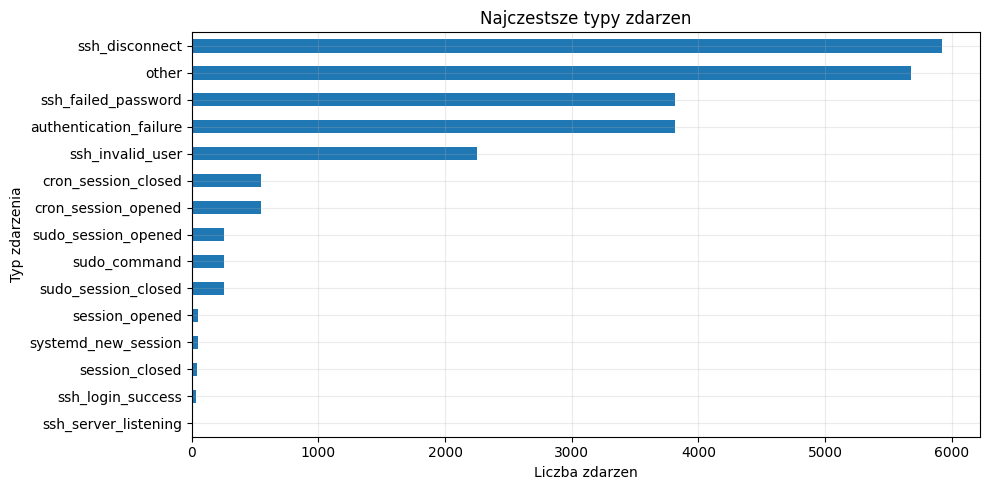

In [4]:
# Wykres 1: najczestsze typy zdarzen.
# Wykres ten prezentuje, czy log jest zdominowany przez zdarzenia SSH, CRON, sudo czy inne uslugi.
ax = event_counts.head(15).sort_values().plot(kind='barh', title='Najczestsze typy zdarzen')
ax.set_xlabel('Liczba zdarzen')
ax.set_ylabel('Typ zdarzenia')
plt.tight_layout()

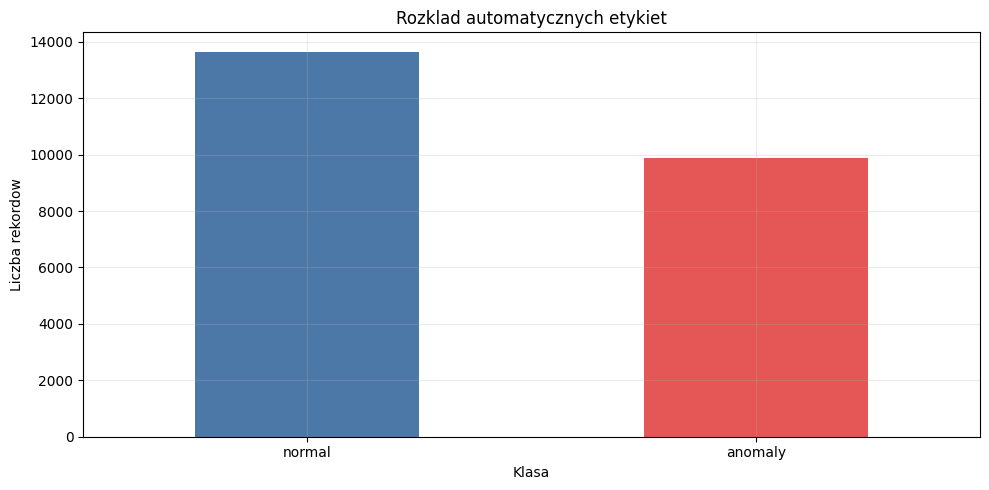

In [5]:
# Wykres 2: udzial rekordow normalnych i anomalii wedlug automatycznych etykiet.
# Wykres ten prezentuje poziom niezbalansowania klas, ktory wplywa na metryki precision/recall/F1.
colors = ['#4c78a8', '#e45756']
ax = label_counts.plot(kind='bar', color=colors, title='Rozklad automatycznych etykiet')
ax.set_xlabel('Klasa')
ax.set_ylabel('Liczba rekordow')
plt.xticks(rotation=0)
plt.tight_layout()

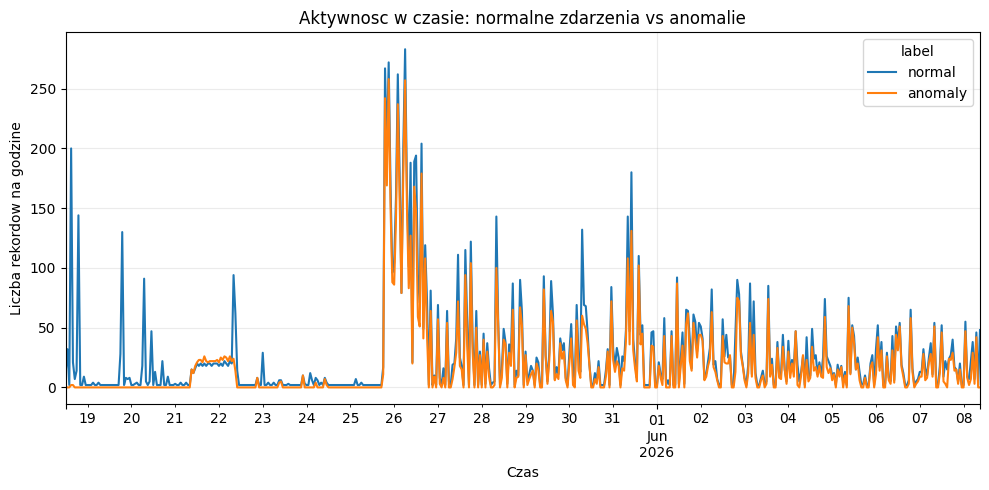

In [6]:
# Wykres 3: liczba zdarzen w czasie, agregacja godzinowa.
# Wykres ten pozwala zobaczyc okresy wzmozonej aktywnosci i potencjalne fale atakow.
time_df = df.dropna(subset=['timestamp']).copy()
time_df['hour_bucket'] = pd.to_datetime(time_df['timestamp']).dt.floor('h')
time_df['label'] = labels.values

hourly = time_df.groupby(['hour_bucket', 'label']).size().unstack(fill_value=0).rename(columns={0: 'normal', 1: 'anomaly'})
ax = hourly.plot(kind='line', title='Aktywnosc w czasie: normalne zdarzenia vs anomalie')
ax.set_xlabel('Czas')
ax.set_ylabel('Liczba rekordow na godzine')
plt.tight_layout()

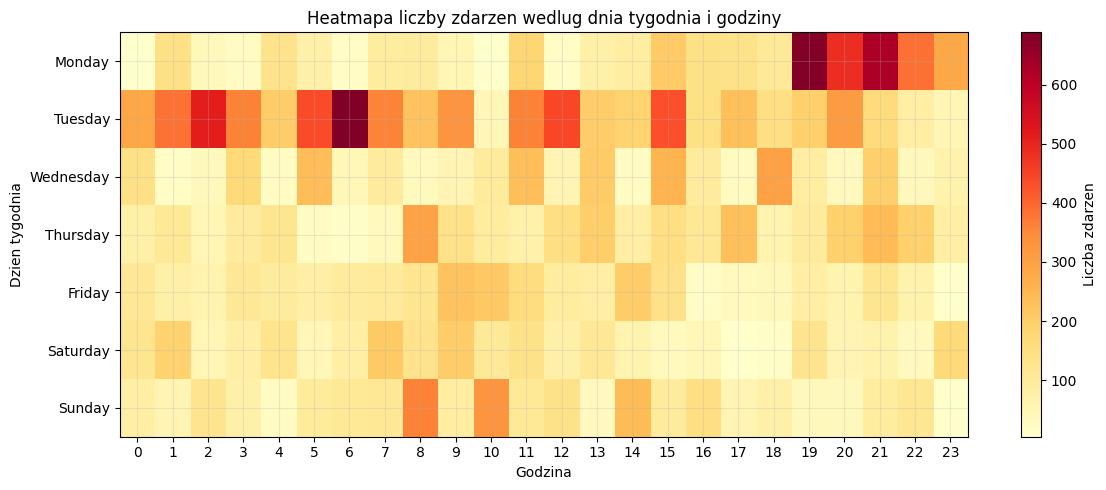

In [7]:
# Wykres 4: heatmapa aktywnosci wedlug dnia tygodnia i godziny.
# Wykres ten pokazuje wartosci w nietypowych godzinach moga wskazywac automatyczne skanowanie lub brute-force.
time_df['day_name'] = pd.to_datetime(time_df['timestamp']).dt.day_name()
time_df['hour'] = pd.to_datetime(time_df['timestamp']).dt.hour
heatmap_data = time_df.pivot_table(index='day_name', columns='hour', values='event_type', aggfunc='count', fill_value=0)
heatmap_data = heatmap_data.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
ax.set_title('Heatmapa liczby zdarzen wedlug dnia tygodnia i godziny')
ax.set_xlabel('Godzina')
ax.set_ylabel('Dzien tygodnia')
ax.set_xticks(range(24))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
fig.colorbar(im, ax=ax, label='Liczba zdarzen')
plt.tight_layout()

## 4. Najczesciej atakowane konta i adresy IP

Dla zdarzen `Failed password`, `Invalid user` i `authentication failure` sprawdzamy, ktore konta i adresy IP pojawiaja sie najczesciej.

Analiza najczesciej atakowanych kont i adresow IP pozwala wskazac potencjalne cele oraz zrodla prob nieautoryzowanego dostepu.

In [8]:
# Wybieramy tylko zdarzenia nieudanych prob uwierzytelnienia.
attacks = df[df['event_type'].isin(['ssh_failed_password', 'ssh_invalid_user', 'authentication_failure'])]

# Najczesciej atakowane nazwy kont.
attacked_users = attacks['user'].dropna().value_counts().head(20)

# Najczesciej wystepujace adresy IP w podejrzanych zdarzeniach.
top_ips = attacks['ip_address'].dropna().value_counts().head(20)

display(attacked_users.to_frame('failed_events'))
display(top_ips.to_frame('failed_events'))

,failed_events
user,
root,3116
ubuntu,482
admin,184
cloud,144
curl,114
user,102
test,58
user1,56
postgres,38


,failed_events
ip_address,
46.151.182.220,582
154.221.28.214,26
40.83.182.122,20
103.132.243.250,19
152.32.129.236,18
81.193.216.17,18
165.154.6.144,18
52.140.76.154,18
62.3.56.187,18


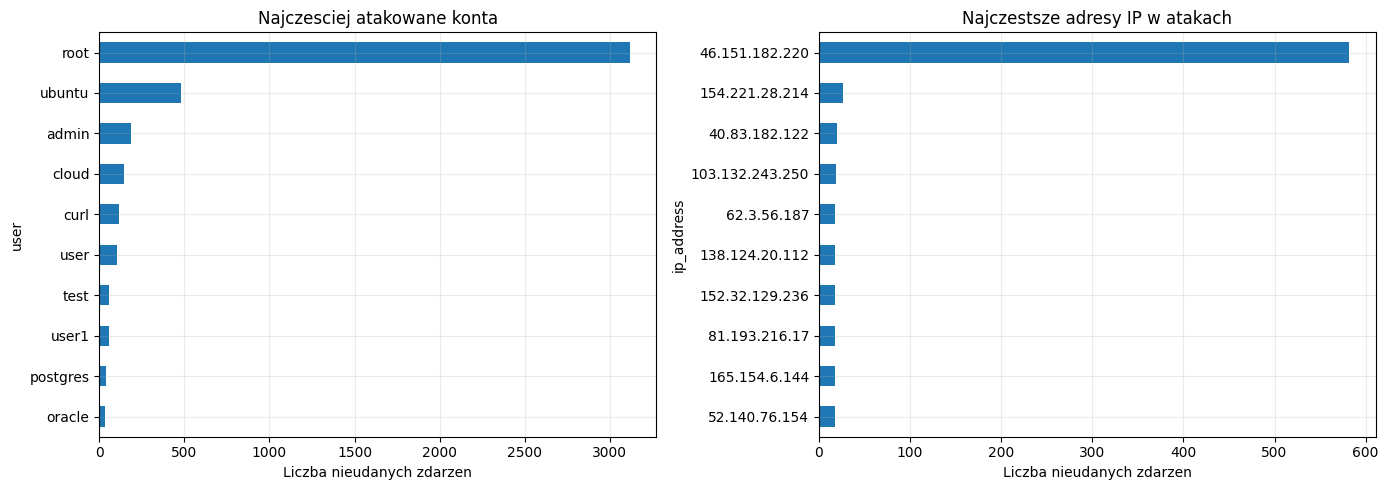

In [9]:
# Wykres 5 i 6: najczesciej atakowane konta oraz najczestsze adresy IP.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
attacked_users.head(10).sort_values().plot(kind='barh', ax=axes[0], title='Najczesciej atakowane konta')
top_ips.head(10).sort_values().plot(kind='barh', ax=axes[1], title='Najczestsze adresy IP w atakach')
axes[0].set_xlabel('Liczba nieudanych zdarzen')
axes[1].set_xlabel('Liczba nieudanych zdarzen')
plt.tight_layout()

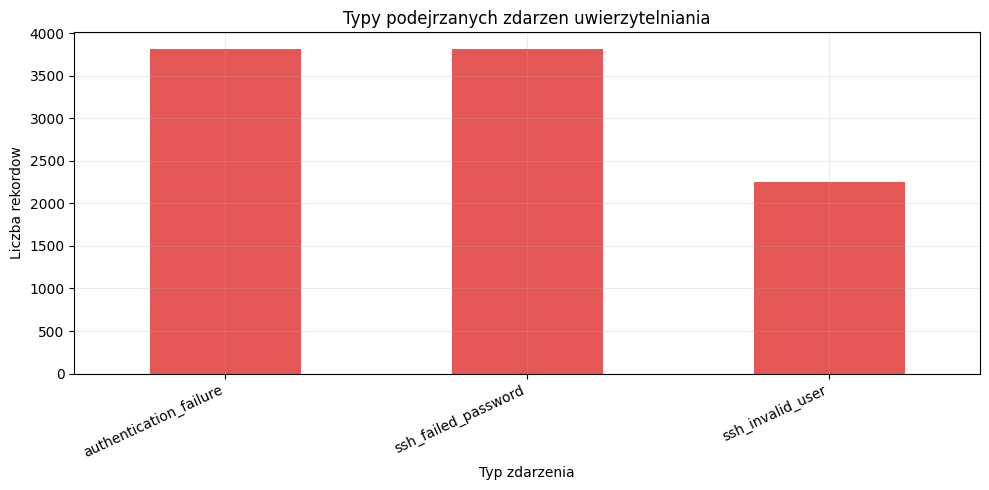

In [10]:
# Wykres 7: rozklad typow podejrzanych zdarzen SSH/PAM.
# Wyjres ten pokazuje, jaki rodzaj problemu dominuje: hasla, nieistniejacy uzytkownicy czy PAM.
attack_type_counts = attacks['event_type'].value_counts()
ax = attack_type_counts.plot(kind='bar', color='#e45756', title='Typy podejrzanych zdarzen uwierzytelniania')
ax.set_xlabel('Typ zdarzenia')
ax.set_ylabel('Liczba rekordow')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()

## 5. Detekcja regulowa

Detekcja regulowa dziala bez uczenia maszynowego. Reguly sa jawne i interpretowalne: wykrywaja m.in.:
- nieudane hasla SSH,
- nieistniejacych uzytkownikow,
- bledy PAM,
- logowanie roota,
- brute-force z jednego IP,
- nietypowe godziny oraz uzycie sudo.

Podejscie regulowe nie wymaga uczenia modelu i opiera sie na wczesniej zdefiniowanych wzorcach charakterystycznych dla incydentow bezpieczenstwa.

In [11]:
stats = calculate_detection_statistics(records)
detections_df = detections_to_dataframe(records)

print(stats)
display(detections_df['rule'].value_counts().to_frame('detections'))
detections_df.head(20)

{'total_logs': 23538, 'anomaly_logs': 10140, 'normal_logs': 13398, 'rule_counter': {'Password change': 1, 'Sudo usage': 251, 'Authentication failure': 3818, 'Failed password': 3818, 'Root login': 3116, 'Invalid user': 2250, 'Unusual hour': 2570, 'Brute-force SSH': 2636}}


,detections
rule,
Authentication failure,3818
Failed password,3818
Root login,3116
Brute-force SSH,2636
Unusual hour,2570
Invalid user,2250
Sudo usage,251
Password change,1


,record_index,timestamp,service,event_type,user,ip_address,rule,reason
0,0,2026-05-18 12:39:25.476189+00:00,passwd,password_changed,danton,NaN,Password change,Password for danton changed by root
1,15,2026-05-18 13:40:47.590310+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/bin/nano /etc/net...
2,18,2026-05-18 13:41:33.552817+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/bin/nano /etc/net...
3,21,2026-05-18 13:45:25.668252+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/sbin/netplan try
4,24,2026-05-18 13:45:33.973712+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/bin/nano /etc/net...
5,27,2026-05-18 13:45:48.724869+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/bin/nano /etc/net...
6,30,2026-05-18 13:45:51.981005+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/sbin/netplan try
7,33,2026-05-18 13:46:37.761886+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/bin/systemctl sta...
8,36,2026-05-18 13:58:44.615964+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/bin/apt get update
9,39,2026-05-18 13:58:50.915383+00:00,sudo,sudo_command,danton,NaN,Sudo usage,sudo by danton as root: /usr/bin/apt update


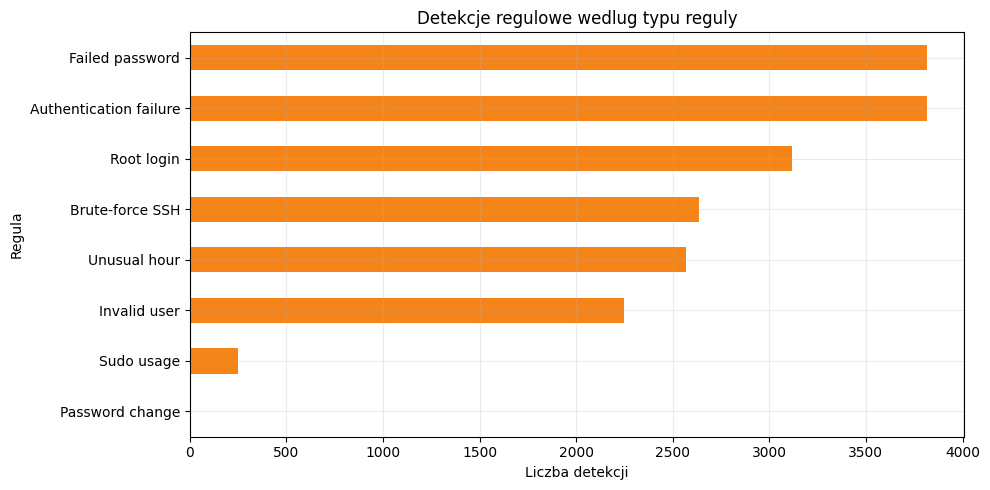

In [12]:
# Wykres 8: liczba detekcji wedlug reguly.
# Wykres ten pokazuje reguly z najwieksza liczba trafien wskazuja dominujacy typ zagrozenia w danych.
rule_counts = detections_df['rule'].value_counts()
ax = rule_counts.sort_values().plot(kind='barh', color='#f58518', title='Detekcje regulowe wedlug typu reguly')
ax.set_xlabel('Liczba detekcji')
ax.set_ylabel('Regula')
plt.tight_layout()

## 6. Cechy dla modeli ML

Modele ML nie analizuja bezposrednio tekstu logu. Kazdy rekord jest zamieniany na zestaw cech liczbowych, np. godzina, dzien tygodnia, typ zdarzenia, dlugosc nazwy uzytkownika, obecnosc IP, port, wynik operacji, flaga sudo/cron oraz liczba nieudanych prob w oknie czasowym.
Jakosc cech ma bezposredni wplyw na skutecznosc wykrywania anomalii przez modele uczenia maszynowego.

In [13]:
# Podglad tabeli cech uzywanej przez Isolation Forest i LOF.
features.head()

,hour,day_of_week,is_weekend,is_night,service_code,event_type_code,user_length,is_root_user,has_ip,ip_code,port,success,is_ssh_event,is_failed_login,is_invalid_user,is_sudo,is_cron,command_length,failed_login_count_window,raw_message_length
0,12,0,0,0,658,692,6,0,0,-1,0,1,0,0,0,0,0,0,0,92
1,12,0,0,0,459,546,0,0,0,-1,0,-1,0,0,0,0,0,0,0,76
2,12,0,0,0,459,546,0,0,0,-1,0,-1,0,0,0,0,0,0,0,120
3,12,0,0,0,459,546,0,0,0,-1,0,-1,0,0,0,0,0,0,0,136
4,12,0,0,0,434,160,0,0,1,330,22,1,1,0,0,0,0,0,0,87


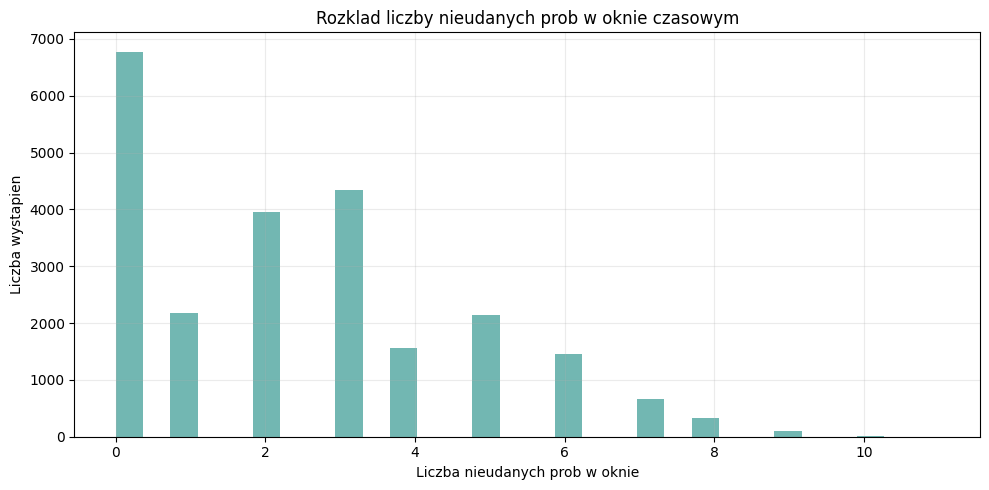

In [14]:
# Wykres 9: histogram liczby nieudanych prob w oknie czasowym.
# Pomaga to modelom i regulom identyfikowac brute-force SSH.
ax = features['failed_login_count_window'].plot(kind='hist', bins=30, color='#72b7b2', title='Rozklad liczby nieudanych prob w oknie czasowym')
ax.set_xlabel('Liczba nieudanych prob w oknie')
ax.set_ylabel('Liczba wystapien')
plt.tight_layout()

## 7. Modele ML: Isolation Forest i Local Outlier Factor

Oba modele traktuja anomalie jako punkty odstajace w przestrzeni cech. W przeciwienstwie do regul, modele nie wiedza jawnie, czym jest `Failed password` lub `Invalid user`; widza tylko liczby opisujace rekord.

Analizuja zaleznosci pomiedzy cechami i wykrywaja rekordy odbiegajace od typowego zachowania obserwowanego w zbiorze danych.

In [15]:
# Trenujemy Isolation Forest i wykonujemy predykcje.
isolation_model = train_isolation_forest(features)
isolation_predictions = predict_anomalies(isolation_model, features)

# Trenujemy Local Outlier Factor i wykonujemy predykcje.
lof_model = train_local_outlier_factor(features)
lof_predictions = predict_local_outlier_factor(lof_model, features)

# Porownujemy liczbe wykrytych anomalii przez kazda metode.
comparison_df = compare_detection_methods(records, isolation_predictions, lof_predictions)
display(comparison_df)

,method,detected_anomalies,percentage,overlap_with_rules
0,Rule-based,10140,43.08,10140
1,Isolation Forest,4707,20.00,1916
2,Local Outlier Factor,4267,18.13,1970


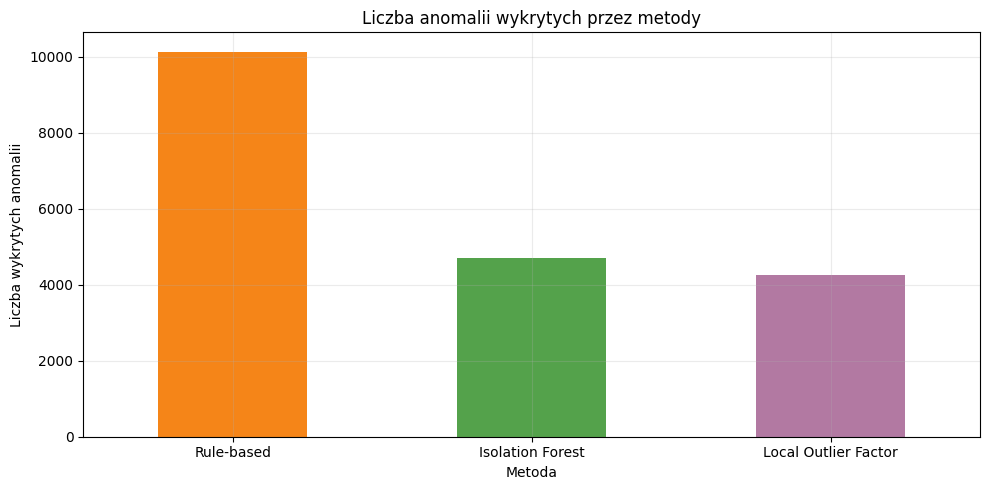

In [16]:
# Wykres 10: ile anomalii wykryla kazda metoda.
ax = comparison_df.set_index('method')['detected_anomalies'].plot(kind='bar', color=['#f58518', '#54a24b', '#b279a2'], title='Liczba anomalii wykrytych przez metody')
ax.set_xlabel('Metoda')
ax.set_ylabel('Liczba wykrytych anomalii')
plt.xticks(rotation=0)
plt.tight_layout()

,category,count
0,Rule only,6839
1,Isolation only,2414
2,LOF only,1920
3,Rule + Isolation,1331
4,Rule + LOF,1385
5,Isolation + LOF,377
6,All methods,585


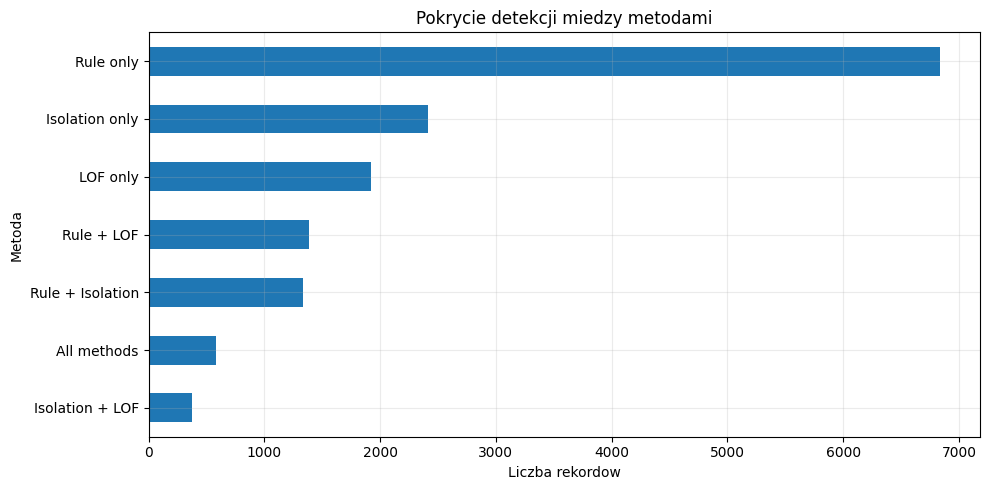

In [22]:
# Wykres 11: pokrycie detekcji miedzy metodami.
# Wykres ten prezentuje, ile wykryc ML pokrywa sie z detekcja regulowa.
rule_indices = set(detections_df['record_index'].unique())
isolation_indices = {index for index, prediction in enumerate(isolation_predictions) if prediction == -1}
lof_indices = {index for index, prediction in enumerate(lof_predictions) if prediction == -1}

overlap_df = pd.DataFrame([
    {'category': 'Rule only', 'count': len(rule_indices - isolation_indices - lof_indices)},
    {'category': 'Isolation only', 'count': len(isolation_indices - rule_indices - lof_indices)},
    {'category': 'LOF only', 'count': len(lof_indices - rule_indices - isolation_indices)},
    {'category': 'Rule + Isolation', 'count': len((rule_indices & isolation_indices) - lof_indices)},
    {'category': 'Rule + LOF', 'count': len((rule_indices & lof_indices) - isolation_indices)},
    {'category': 'Isolation + LOF', 'count': len((isolation_indices & lof_indices) - rule_indices)},
    {'category': 'All methods', 'count': len(rule_indices & isolation_indices & lof_indices)},
])

display(overlap_df)
ax = overlap_df.set_index('category')['count'].sort_values().plot(kind='barh', title='Pokrycie detekcji miedzy metodami')
ax.set_xlabel('Liczba rekordow')
ax.set_ylabel('Metoda')
plt.tight_layout()

## 8. Confusion matrix i metryki

Metryki sa liczone wzgledem automatycznych etykiet. Etykiety nie pochodza z recznej analizy, tylko z jasnych wzorcow w logach. Dlatego wyniki nalezy interpretowac jako porownanie metod wobec przyjetej definicji anomalii.

Do oceny metod wykorzystano Accuracy, Precision, Recall oraz F1-score. Metryki te pozwalaja porownac skutecznosc detekcji oraz liczbe generowanych falszywych alarmow.

In [18]:
metrics_df = calculate_labeled_metrics(records, labels, isolation_predictions, lof_predictions)
matrices = confusion_matrices(records, labels, isolation_predictions, lof_predictions)

display(metrics_df)
for method, matrix in matrices.items():
    print(method)
    display(matrix)

,method,tp,fp,tn,fn,accuracy,precision,recall,f1
0,Rule-based,9886,254,13398,0,98.92,97.50,100.00,98.73
1,Isolation Forest,1662,3045,10607,8224,52.12,35.31,16.81,22.78
2,Local Outlier Factor,1890,2377,11275,7996,55.93,44.29,19.12,26.71


Rule-based


,pred_0,pred_1
actual_0,13398,254
actual_1,0,9886


Isolation Forest


,pred_0,pred_1
actual_0,10607,3045
actual_1,8224,1662


Local Outlier Factor


,pred_0,pred_1
actual_0,11275,2377
actual_1,7996,1890


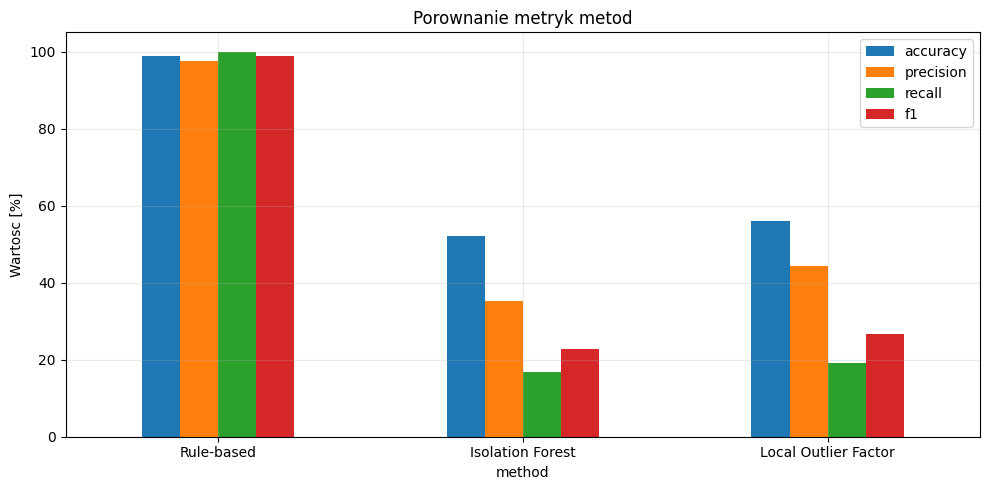

In [19]:
# Wykres 12: porownanie czterech metryk metod.
metric_plot = metrics_df.set_index('method')[['accuracy', 'precision', 'recall', 'f1']]
ax = metric_plot.plot(kind='bar', title='Porownanie metryk metod')
ax.set_ylabel('Wartosc [%]')
ax.set_ylim(0, 105)
plt.xticks(rotation=0)
plt.tight_layout()

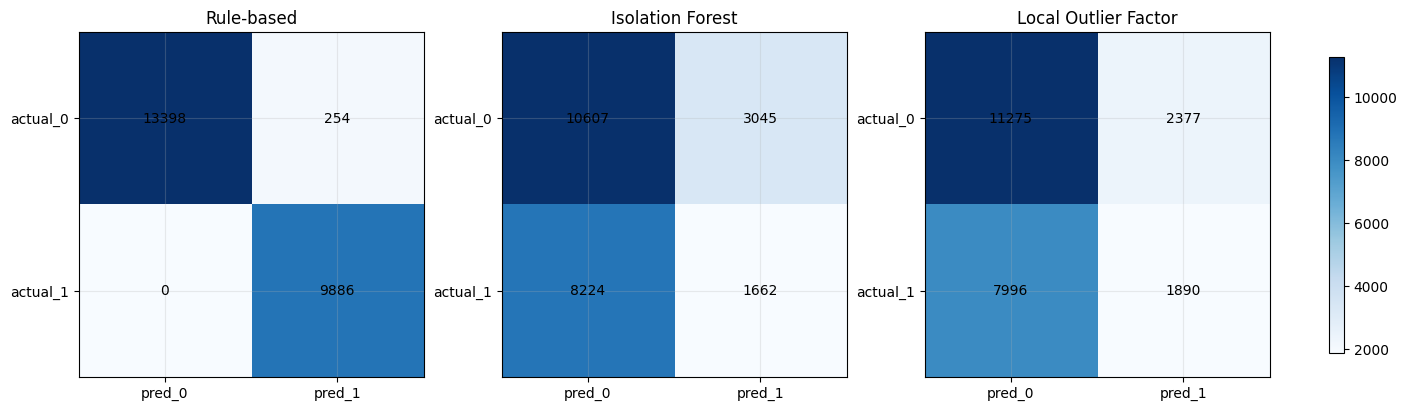

In [20]:
# Wykres 13: confusion matrix jako heatmapy.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, (method, matrix) in zip(axes, matrices.items()):
    im = ax.imshow(matrix.values, cmap='Blues')
    ax.set_title(method)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(matrix.index)
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, int(matrix.values[row, col]), ha='center', va='center', color='black')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

## 9. Wnioski z wynikow

Automatyczne wnioski na podstawie tabel.

In [21]:
best_f1 = metrics_df.sort_values('f1', ascending=False).iloc[0]
best_precision = metrics_df.sort_values('precision', ascending=False).iloc[0]
best_recall = metrics_df.sort_values('recall', ascending=False).iloc[0]

rule_row = metrics_df[metrics_df['method'] == 'Rule-based'].iloc[0]
if_row = metrics_df[metrics_df['method'] == 'Isolation Forest'].iloc[0]
lof_row = metrics_df[metrics_df['method'] == 'Local Outlier Factor'].iloc[0]

print('\nWNIOSKI O DETEKCJI REGULOWEJ')
print(f'- Detekcja regulowa uzyskala F1={rule_row.f1}%, precision={rule_row.precision}% i recall={rule_row.recall}%.')
print('- Reguly bardzo dobrze wykrywaly zdarzenia oznaczone jako anomalie.')
print('- Wysoki wynik wynika z tego, ze etykiety referencyjne zostaly utworzone na podstawie podobnych wzorcow wystepujacych w logach.')
print('- Zaleta podejscia regulowego jest prostota oraz latwa interpretacja wynikow.')

print('\nWNIOSKI O MODELACH ML')
print(f'- Isolation Forest uzyskal F1={if_row.f1}%, precision={if_row.precision}% i recall={if_row.recall}%.')
print(f'- Local Outlier Factor uzyskal F1={lof_row.f1}%, precision={lof_row.precision}% i recall={lof_row.recall}%.')
print('- Modele ML wykrywaly rekordy odbiegajace od typowego zachowania w zbiorze danych.')
print('- Uzyskaly nizszy recall od detekcji regulowej, przez co wykryly mniej oznaczonych anomalii.')
print('- Poszczegolne modele oznaczaly czesciowo rozne rekordy jako podejrzane.')

print('\nPOROWNANIE METOD')
print(f'- Najwyzszy F1: {best_f1.method} ({best_f1.f1}%).')
print(f'- Najwyzsza precision: {best_precision.method} ({best_precision.precision}%).')
print(f'- Najwyzszy recall: {best_recall.method} ({best_recall.recall}%).')
print('- W analizowanym zbiorze najlepsze wyniki uzyskala detekcja regulowa.')
print('- Metody ML nie zastapily regul, ale pozwolily wykryc dodatkowe rekordy odbiegajace od typowego zachowania.')
print('- Polaczenie detekcji regulowej i metod ML moze zwiekszyc skutecznosc wykrywania podejrzanych zdarzen.')
print('- Wyniki nalezy interpretowac z uwzglednieniem sposobu automatycznego etykietowania danych.')


WNIOSKI O DETEKCJI REGULOWEJ
- Detekcja regulowa uzyskala F1=98.73%, precision=97.5% i recall=100.0%.
- Reguly bardzo dobrze wykrywaly zdarzenia oznaczone jako anomalie.
- Wysoki wynik wynika z tego, ze etykiety referencyjne zostaly utworzone na podstawie podobnych wzorcow wystepujacych w logach.
- Zaleta podejscia regulowego jest prostota oraz latwa interpretacja wynikow.

WNIOSKI O MODELACH ML
- Isolation Forest uzyskal F1=22.78%, precision=35.31% i recall=16.81%.
- Local Outlier Factor uzyskal F1=26.71%, precision=44.29% i recall=19.12%.
- Modele ML wykrywaly rekordy odbiegajace od typowego zachowania w zbiorze danych.
- Uzyskaly nizszy recall od detekcji regulowej, przez co wykryly mniej oznaczonych anomalii.
- Poszczegolne modele oznaczaly czesciowo rozne rekordy jako podejrzane.

POROWNANIE METOD
- Najwyzszy F1: Rule-based (98.73%).
- Najwyzsza precision: Rule-based (97.5%).
- Najwyzszy recall: Rule-based (100.0%).
- W analizowanym zbiorze najlepsze wyniki uzyskala detekcja regu

## 10. Wnioski koncowe
- W analizowanych logach najczesciej wystepowaly nieudane logowania SSH oraz proby logowania na nieistniejace konta.
- Detekcja regulowa uzyskala najlepsze wyniki, poniewaz opierala sie na charakterystycznych wzorcach wystepujacych w logach..
- Isolation Forest i LOF wykrywaly mniej anomalii, ale pokazuja mozliwosc zastosowania metod ML do analizy logow systemowych.
- Polaczenie detekcji regulowej i ML moze zwiekszyc skutecznosc wykrywania podejrzanych zdarzen.